In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [9]:
#2
file_path = Path("creditcard.csv")

if not file_path.exists():
    print(f"[❌ ERROR] Dataset file not found at: {file_path.resolve()}")
    print("👉 Please download it from Kaggle and place it in the same folder.")
else:
    print(f"[✅] Found dataset file: {file_path}")
    df = pd.read_csv(file_path)


[✅] Found dataset file: creditcard.csv


In [10]:
#3
# Confirm columns
print("[📋] Columns:", df.columns.tolist())

# Ensure required columns exist
required = ['Time', 'Amount', 'Class']
for col in required:
    if col not in df.columns:
        print(f"[❌] Missing column: {col}")
        exit()


[📋] Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [11]:
#4
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df = df.drop(['Time', 'Amount'], axis=1)


In [12]:
#5
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (227845, 30)
X_test shape: (56962, 30)


In [13]:
#6
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✅ Model training complete")


✅ Model training complete


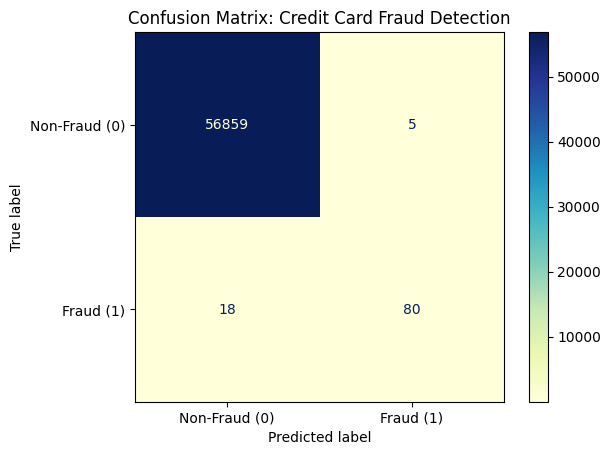

In [17]:
# Confusion Matrix - styled like before
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud (0)', 'Fraud (1)'])
disp.plot(cmap='YlGnBu', values_format='d')
plt.title('Confusion Matrix: Credit Card Fraud Detection')
plt.grid(False)
plt.show()


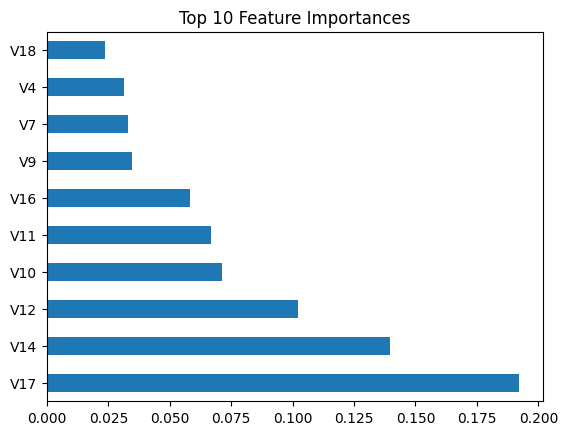

In [15]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()


In [16]:
#9
joblib.dump(model, 'fraud_detection_model.pkl')
print("💾 Model saved as 'fraud_detection_model.pkl'")


💾 Model saved as 'fraud_detection_model.pkl'
